# AdapterDrop + Compacter 交互教学

配套 lecture: [../lectures/03-adapterdrop-compacter.md](../lectures/03-adapterdrop-compacter.md)

本 notebook 演示:
1. Kronecker 积可视化
2. PHM 参数量计算
3. Compacter vs Pfeiffer vs Houlsby 三方对比
4. AdapterDrop 推理加速演示

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from adapterdrop_minimal import AdapterDropGPT2
from compacter_minimal import CompacterGPT2, PHMLinear, kronecker, CompacterAdapter
from pfeiffer_minimal import PfeifferGPT2
from houlsby_minimal import HoulsbyGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Kronecker 积可视化（n=2 玩具例子）

A:
tensor([[1., 2.],
        [3., 4.]])

B:
tensor([[5., 6.],
        [7., 8.]])

A ⊗ B:
tensor([[ 5.,  6., 10., 12.],
        [ 7.,  8., 14., 16.],
        [15., 18., 20., 24.],
        [21., 24., 28., 32.]])

shape: A torch.Size([2, 2]) ⊗ B torch.Size([2, 2]) = torch.Size([4, 4])


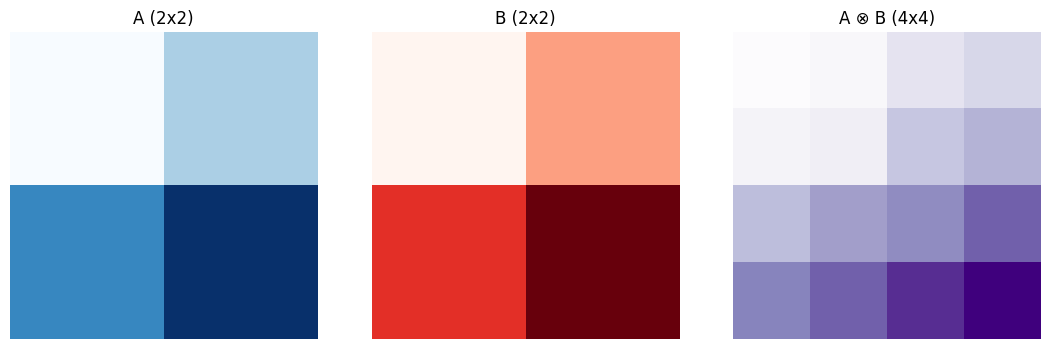

In [2]:
A = torch.tensor([[1., 2.], [3., 4.]])
B = torch.tensor([[5., 6.], [7., 8.]])
K = kronecker(A, B)
print(f'A:\n{A}')
print(f'\nB:\n{B}')
print(f'\nA \u2297 B:\n{K}')
print(f'\nshape: A {A.shape} \u2297 B {B.shape} = {K.shape}')

# 可视化 heatmap
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(A, cmap='Blues'); axes[0].set_title('A (2x2)'); axes[0].axis('off')
axes[1].imshow(B, cmap='Reds'); axes[1].set_title('B (2x2)'); axes[1].axis('off')
axes[2].imshow(K, cmap='Purples'); axes[2].set_title('A \u2297 B (4x4)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

## 2. PHM 参数量随 n 变化

n= 1: 13,057  (vs normal Linear 13,056)
n= 2:  6,920  (vs normal Linear 13,056)
n= 4:  3,904  (vs normal Linear 13,056)
n= 8:  2,816  (vs normal Linear 13,056)
n=16:  5,632  (vs normal Linear 13,056)


C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\3190209376.py:18: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\3190209376.py:18: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\3190209376.py:18: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UN

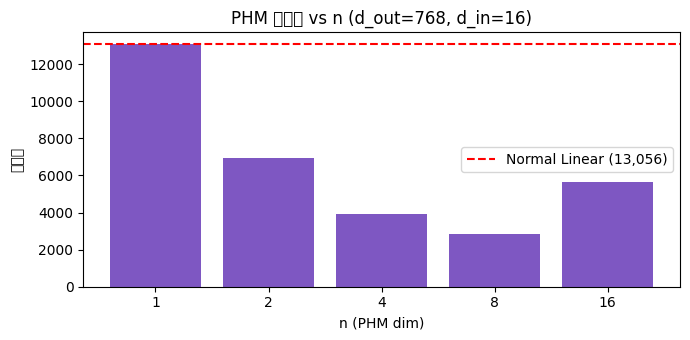

In [3]:
d_out, d_in = 768, 16
ns = [1, 2, 4, 8, 16]
results = []
for n in ns:
    if d_out % n != 0 or d_in % n != 0:
        continue
    layer = PHMLinear(d_in, d_out, n=n)
    params = sum(p.numel() for p in layer.parameters())
    results.append((n, params))
    print(f'n={n:>2}: {params:>6,}  (vs normal Linear {d_out*d_in + d_out:,})')

ns_, ps_ = zip(*results)
plt.figure(figsize=(7, 3.5))
plt.bar([str(n) for n in ns_], ps_, color='#7e57c2')
plt.axhline(y=d_out * d_in + d_out, color='red', linestyle='--', label=f'Normal Linear ({d_out*d_in + d_out:,})')
plt.xlabel('n (PHM dim)'); plt.ylabel('参数量')
plt.title(f'PHM 参数量 vs n (d_out={d_out}, d_in={d_in})')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Compacter vs Pfeiffer vs Houlsby 参数量

Houlsby r=16                 608,640
Pfeiffer r=16                304,320
Compacter r=16, n=4           83,264


C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\664589495.py:22: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\664589495.py:22: UserWarning: Glyph 26063 (\N{CJK UNIFIED IDEOGRAPH-65CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\664589495.py:22: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\664589495.py:22: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\664589495.py:22: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipyker

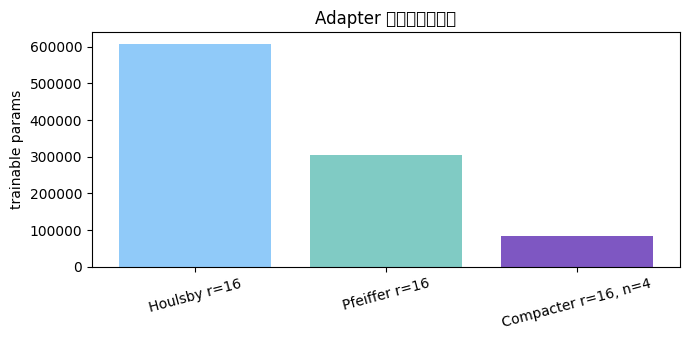

In [4]:
torch.manual_seed(42)
compacter = CompacterGPT2(r=16, n=4)
pfeiffer = PfeifferGPT2(r=16)
houlsby = HoulsbyGPT2(r=16)

data = [
    ('Houlsby r=16', sum(p.numel() for p in houlsby.parameters() if p.requires_grad)),
    ('Pfeiffer r=16', sum(p.numel() for p in pfeiffer.parameters() if p.requires_grad)),
    ('Compacter r=16, n=4', sum(p.numel() for p in compacter.parameters() if p.requires_grad)),
]

for name, p in data:
    print(f'{name:<25} {p:>10,}')

names = [d[0] for d in data]
params = [d[1] for d in data]
plt.figure(figsize=(7, 3.5))
plt.bar(names, params, color=['#90caf9', '#80cbc4', '#7e57c2'])
plt.ylabel('trainable params')
plt.title('Adapter 家族参数量对比')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 4. AdapterDrop 推理时延模拟

12 层 active: 47.70 ms/iter


k= 0 (12 layers active): 48.80 ms/iter  (102.3% of full)


k= 3 (9 layers active): 46.84 ms/iter  (98.2% of full)


k= 6 (6 layers active): 46.31 ms/iter  (97.1% of full)


k= 9 (3 layers active): 47.47 ms/iter  (99.5% of full)


C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\2170675288.py:33: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\2170675288.py:33: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\2170675288.py:33: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\2170675288.py:33: UserWarning: Glyph 24310 (\N{CJK UNIFIED IDEOGRAPH-5EF6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_46212\2170675288.py:33: UserWarning: Glyph 20002 (\N{CJK UNIFIED IDEOGRAPH-4E22}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\i

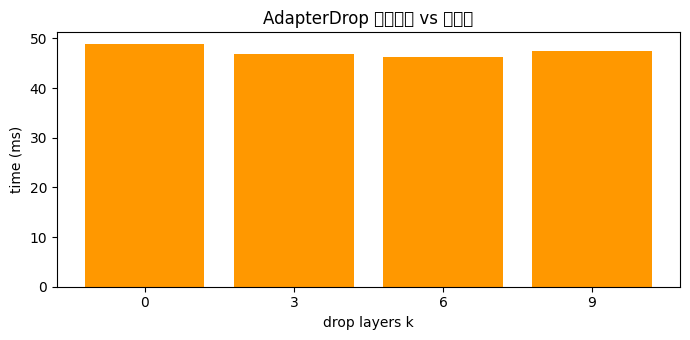

In [5]:
import time
torch.manual_seed(42)
model = AdapterDropGPT2(r=16).eval()
tok = model.tokenizer
enc = tok('hello world ' * 50, return_tensors='pt')

# 基准: 不丢
model.set_inference_drop(k=0)
torch.cuda.empty_cache()
with torch.no_grad():
    for _ in range(3): model(**enc)  # warmup
    t0 = time.time()
    for _ in range(20): model(**enc)
    t_full = (time.time() - t0) / 20
print(f'12 层 active: {t_full*1000:.2f} ms/iter')

ks = [0, 3, 6, 9]
times = []
for k in ks:
    model.set_inference_drop(k=k)
    with torch.no_grad():
        for _ in range(3): model(**enc)
        t0 = time.time()
        for _ in range(20): model(**enc)
        t = (time.time() - t0) / 20
    times.append(t * 1000)
    print(f'k={k:>2} ({12-k} layers active): {t*1000:.2f} ms/iter  ({100*t/t_full:.1f}% of full)')

plt.figure(figsize=(7, 3.5))
plt.bar([str(k) for k in ks], times, color='#ff9800')
plt.xlabel('drop layers k'); plt.ylabel('time (ms)')
plt.title('AdapterDrop 推理时延 vs 丢层数')
plt.tight_layout(); plt.show()

## 5. Compacter mini training

Compacter 因为参数极少，收敛会比 Pfeiffer 慢。

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


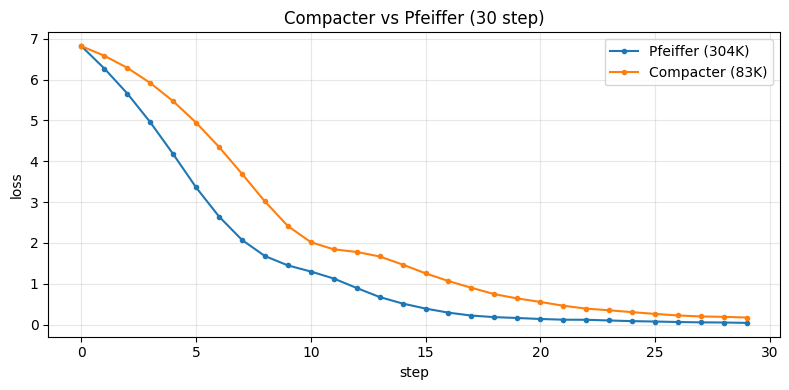

     Pfeiffer (304K) final: 0.0416
     Compacter (83K) final: 0.1727


In [6]:
torch.manual_seed(42)
compacter = CompacterGPT2(r=16, n=4)
torch.manual_seed(42)
pfeiffer = PfeifferGPT2(r=16)

tok = compacter.tokenizer
inputs = tok([
    'hello world this is a test', 'i love this amazing product',
    'absolutely terrible movie', 'fantastic experience'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('Pfeiffer (304K)', pfeiffer, torch.optim.AdamW([p for p in pfeiffer.parameters() if p.requires_grad], lr=1e-3)),
    ('Compacter (83K)', compacter, torch.optim.AdamW([p for p in compacter.parameters() if p.requires_grad], lr=3e-3)),
]

losses = {n: [] for n, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for n in losses:
    plt.plot(losses[n], label=n, marker='o', markersize=3)
plt.xlabel('step'); plt.ylabel('loss')
plt.title('Compacter vs Pfeiffer (30 step)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
for n in losses: print(f'{n:>20} final: {losses[n][-1]:.4f}')

## 6. 思考题

1. n=8 vs n=4 在 d=768 时哪个参数更少？验证一下。
2. 把 AdapterDrop 的 drop_prob 设为 0.3 训练，看收敛差异。
3. 用 Compacter 时 lr 通常要比 Pfeiffer 大 2-3x，为什么？

下节: **Parallel Adapter** — 串联 vs 并联结构